1 .Chargement et prétraitement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Load the 'california_housing_train.csv' file from the 'sample_data' directory
demo_df = pd.read_csv('sample_data/california_housing_train.csv')

# Display the first 5 rows to verify loading
display(demo_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


2. États avec le plus de ventes

In [16]:
display(demo_df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


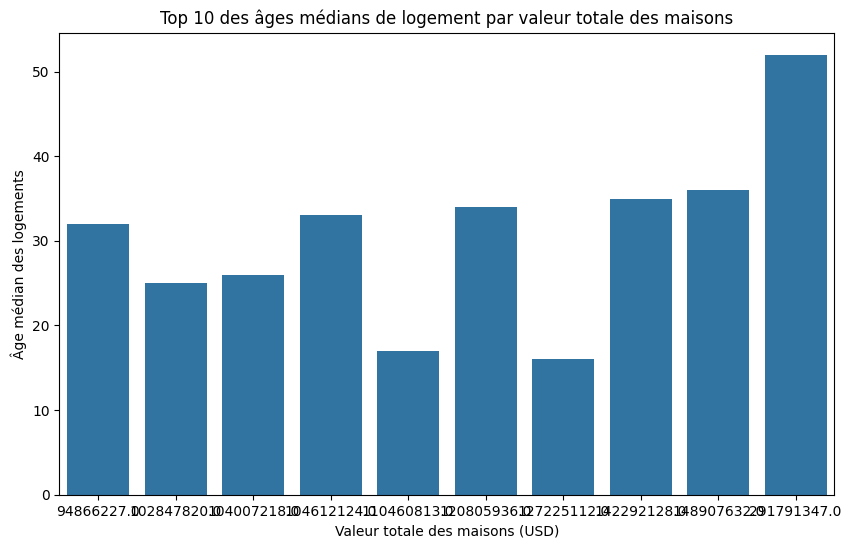

In [17]:
ventes_par_etat = demo_df.groupby('housing_median_age')['median_house_value'].sum().sort_values(ascending=False)
top10_etats_ventes = ventes_par_etat.head(10)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(x=top10_etats_ventes.values, y=top10_etats_ventes.index)
plt.title('Top 10 des âges médians de logement par valeur totale des maisons')
plt.xlabel('Valeur totale des maisons (USD)')
plt.ylabel('Âge médian des logements')
plt.show()

3. Comparaison New York vs Californie

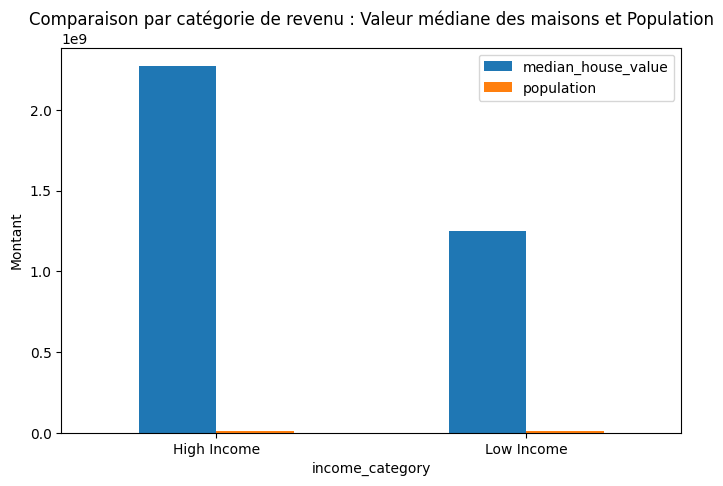

In [21]:
# Calculate the median income to create categories
median_income_threshold = demo_df['median_income'].median()

# Create a new column for income category
demo_df['income_category'] = ['High Income' if x >= median_income_threshold else 'Low Income' for x in demo_df['median_income']]

# Group by income category and calculate sums of median_house_value and population
comparaison_income = demo_df.groupby('income_category')[['median_house_value', 'population']].sum()

# Graphique comparatif
comparaison_income.plot(kind='bar', figsize=(8,5))
plt.title('Comparaison par catégorie de revenu : Valeur médiane des maisons et Population')
plt.ylabel('Montant')
plt.xticks(rotation=0)
plt.show()

4 .Client exceptionnel à New York

In [26]:
highest_value_district = demo_df.sort_values(by='median_house_value', ascending=False).head(1)

if not highest_value_district.empty:
    latitude = highest_value_district['latitude'].iloc[0]
    longitude = highest_value_district['longitude'].iloc[0]
    median_house_value = highest_value_district['median_house_value'].iloc[0]
    print(f"Quartier exceptionnel : Latitude {latitude}, Longitude {longitude} avec {median_house_value:,.0f} USD de valeur médiane de maison.")
else:
    print("Aucun quartier trouvé.")

Quartier exceptionnel : Latitude 35.3, Longitude -120.67 avec 500,001 USD de valeur médiane de maison.



5. Différence de rentabilité entre États




In [28]:
rentabilite_age = demo_df.groupby('housing_median_age').agg({'median_house_value': 'sum', 'total_rooms': 'sum'})
rentabilite_age['Value per Room ($)'] = (rentabilite_age['median_house_value'] / rentabilite_age['total_rooms'])
rentabilite_age_sorted = rentabilite_age.sort_values('Value per Room ($)', ascending=False)

# Top 10 des âges médians de logement par valeur par pièce
print(rentabilite_age_sorted.head(10)[['Value per Room ($)']])

                    Value per Room ($)
housing_median_age                    
52.0                        148.464782
51.0                        130.826582
50.0                        126.504485
48.0                        126.394217
45.0                        124.778643
44.0                        120.352154
41.0                        119.338593
43.0                        115.426299
37.0                        114.862832
49.0                        114.432233


6. Principe de Pareto clients vs bénéfices

55.8% des catégories d'âge de logement génèrent 80% de la valeur totale des maisons


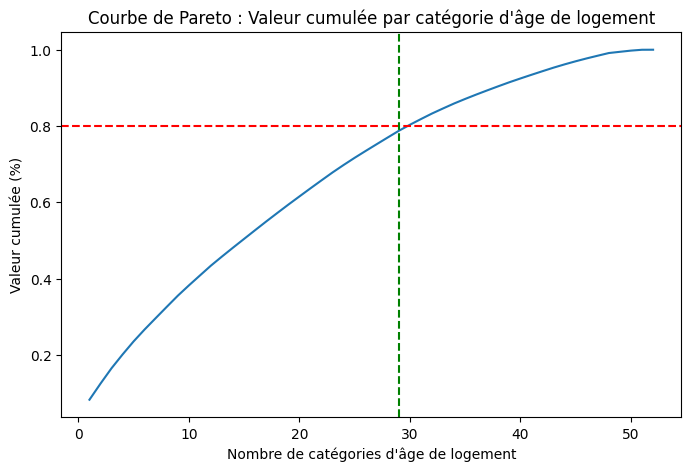

In [30]:
age_categories_value = demo_df.groupby('housing_median_age')['median_house_value'].sum().sort_values(ascending=False)
cumul_value = age_categories_value.cumsum() / age_categories_value.sum()

# Trouver le % des catégories d'âge qui génèrent 80% de la valeur totale
n_categories_80 = (cumul_value <= 0.8).sum()
pct_categories = n_categories_80 / len(age_categories_value) * 100

print(f"{pct_categories:.1f}% des catégories d'âge de logement génèrent 80% de la valeur totale des maisons")

# Tracer la courbe de Pareto
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumul_value)+1), cumul_value)
plt.axhline(y=0.8, color='r', linestyle='--')
plt.axvline(x=n_categories_80, color='g', linestyle='--')
plt.title('Courbe de Pareto : Valeur cumulée par catégorie d\'âge de logement')
plt.xlabel('Nombre de catégories d\'âge de logement')
plt.ylabel('Valeur cumulée (%)')
plt.show()

7. Top 20 villes par ventes et par bénéfice

In [32]:
grouped_locations = demo_df.groupby(['latitude', 'longitude']).agg({
    'median_house_value': 'sum',
    'population': 'sum'
})

top20_value_locations = grouped_locations['median_house_value'].sort_values(ascending=False).head(20)
top20_population_locations = grouped_locations['population'].sort_values(ascending=False).head(20)

# Comparaison des classements
comparaison_locations = pd.DataFrame({
    'Value_rank': top20_value_locations.rank(ascending=False),
    'Population_rank': top20_population_locations.rank(ascending=False)
})
print(comparaison_locations)

# Observation : Une ville peut être top ventes mais peu rentable (ex: forte réduction).

                    Value_rank  Population_rank
latitude longitude                             
33.35    -117.42           NaN              1.0
33.78    -118.16           NaN             12.0
33.89    -117.74           NaN              9.0
33.97    -118.18           NaN             15.0
34.01    -118.47          15.0              NaN
34.03    -117.78           NaN             11.0
34.04    -117.87           NaN             13.0
34.06    -118.31          14.0             17.0
         -118.30           NaN             18.0
         -118.29           NaN              6.0
         -118.03           NaN             19.0
34.07    -118.37          18.0              NaN
         -118.30           NaN              4.0
         -118.28           NaN             14.0
34.09    -118.37          17.0              NaN
         -118.30           NaN             10.0
         -118.29           NaN             16.0
34.10    -118.30           NaN              5.0
34.23    -118.46           NaN          

8. Top 20 clients par ventes

In [34]:
top20_locations_by_value = demo_df.groupby(['latitude', 'longitude'])['median_house_value'].sum().sort_values(ascending=False).head(20)
print(top20_locations_by_value)

latitude  longitude
37.80     -122.41      5495905.0
37.79     -122.44      4968808.0
37.80     -122.44      4500008.0
          -122.42      4115805.0
37.75     -122.43      3619000.0
37.79     -122.43      3410005.0
37.78     -122.44      3377200.0
37.77     -122.45      3271503.0
          -122.44      3269003.0
37.78     -122.46      3154201.0
37.80     -122.43      2941703.0
37.77     -122.43      2792100.0
37.76     -122.44      2778700.0
34.06     -118.31      2716401.0
34.01     -118.47      2706100.0
37.75     -122.42      2687500.0
34.09     -118.37      2650002.0
34.07     -118.37      2594100.0
37.79     -122.41      2522502.0
37.78     -122.49      2507401.0
Name: median_house_value, dtype: float64


9. Courbe cumulative des ventes par client (Pareto)

50.7% des localisations (latitude, longitude) génèrent 80% de la valeur totale des maisons


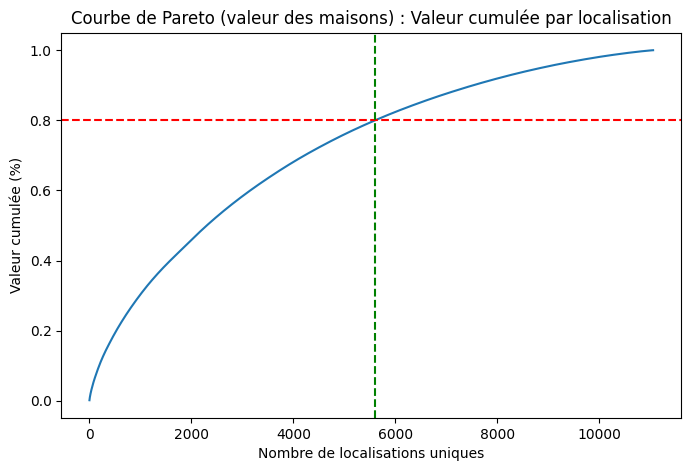

In [36]:
locations_value = demo_df.groupby(['latitude', 'longitude'])['median_house_value'].sum().sort_values(ascending=False)
cumul_locations_value = locations_value.cumsum() / locations_value.sum()

n_locations_80 = (cumul_locations_value <= 0.8).sum()
pct_locations = (n_locations_80 / len(locations_value)) * 100

print(f"{pct_locations:.1f}% des localisations (latitude, longitude) génèrent 80% de la valeur totale des maisons")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumul_locations_value)+1), cumul_locations_value)
plt.axhline(y=0.8, color='r', linestyle='--')
plt.axvline(x=n_locations_80, color='g', linestyle='--')
plt.title('Courbe de Pareto (valeur des maisons) : Valeur cumulée par localisation')
plt.xlabel('Nombre de localisations uniques')
plt.ylabel('Valeur cumulée (%)')
plt.show()